In [1]:
import joblib

In [2]:
graph = joblib.load("grafo.jpkl")

In [3]:
graph

In [17]:
import networkx as nx
from igraph import Graph, plot

def nx_to_igraph(G_nx: nx.DiGraph) -> Graph:
    # Create igraph directed graph
    G_ig = Graph(directed=True)

    # Add nodes (igraph uses integer indices 0..n-1)
    nodes = list(G_nx.nodes())
    G_ig.add_vertices(len(nodes))

    # map node => index in igraph
    index = {node: i for i, node in enumerate(nodes)}

    # Add edges
    edge_list = [(index[u], index[v]) for u, v in G_nx.edges()]
    G_ig.add_edges(edge_list)

    return G_ig, nodes

In [18]:
igraph_graph, nodes = nx_to_igraph(graph)

In [21]:
import numpy as np

In [52]:
fas = igraph_graph.feedback_arc_set(method="ip")
# for a in fas:

igraph_graph.delete_edges(fas)
nodes = np.asarray(nodes)
nodes[igraph_graph.topological_sorting()]
# plot(igraph_graph)

array(['BTC', 'BNB', 'LTC', 'ETH', 'XRP', 'DOGE', 'XLM', 'LINK', 'ADA'],
      dtype='<U4')

In [53]:
igraph_graph.is_dag()

True

In [63]:
igraph_graph.topological_sorting?


Signature: igraph_graph.topological_sorting(mode='out')
Docstring:
Calculates a possible topological sorting of the graph.

Returns a partial sorting and issues a warning if the graph is not
a directed acyclic graph.

@param mode: if C{"out"}, vertices are returned according to the
  forward topological order -- all vertices come before their
  successors. If C{"in"}, all vertices come before their ancestors.
@return: a possible topological ordering as a list
Type:      builtin_function_or_method

In [59]:
networkx_graph = igraph_graph.to_networkx()

In [65]:
import networkx as nx

In [ ]:
nx.all_topological_sorts(networkx_graph)

Signature: nx.all_topological_sorts(G, *, backend=None, **backend_kwargs)
Docstring:
Returns a generator of _all_ topological sorts of the directed graph G.

A topological sort is a nonunique permutation of the nodes such that an
edge from u to v implies that u appears before v in the topological sort
order.

Parameters
----------
G : NetworkX DiGraph
    A directed graph

Yields
------
topological_sort_order : list
    a list of nodes in `G`, representing one of the topological sort orders

Raises
------
NetworkXNotImplemented
    If `G` is not directed
NetworkXUnfeasible
    If `G` is not acyclic

Examples
--------
To enumerate all topological sorts of directed graph:

>>> DG = nx.DiGraph([(1, 2), (2, 3), (2, 4)])
>>> list(nx.all_topological_sorts(DG))
[[1, 2, 4, 3], [1, 2, 3, 4]]

Notes
-----
Implements an iterative version of the algorithm given in [1].

References
----------
.. [1] Knuth, Donald E., Szwarcfiter, Jayme L. (1974).
   "A Structured Program to Generate All Topological

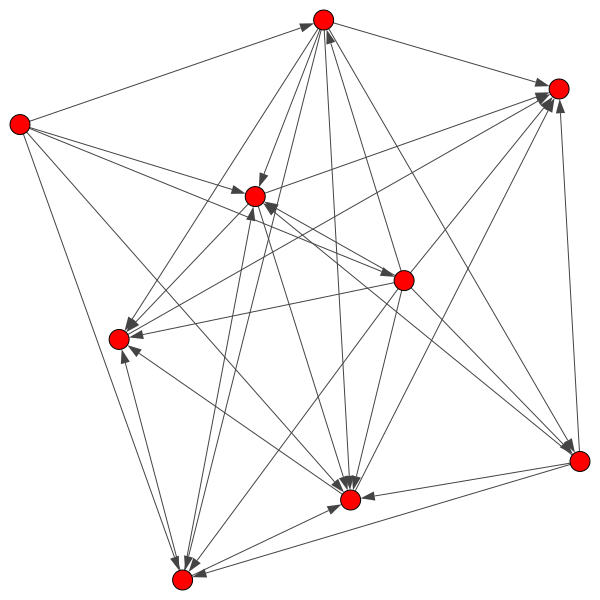

In [62]:


plot(igraph_graph.from_networkx(networkx_graph))